# Measurement agreement of the optical sensors: Piccolo Doppio (FLMS, QEP), ASD, SVC, Altum and REMX

**Reference:** Werfeli, M., Antala, M., Abdelmajeed, A.Y.A., Sánchez-Virosta, Á., Halem, Z., Merrington, A., El-Mejjaouy, Y., Petrovic, B., Hueni, A., Bouras, E.H., Kefauver, S.C., Shafiee, S., Rastogi, A., Mihai, L. (2026). *Uncertainty propagation and intercomparison of multi-sensor measurements of vegetation stress in sub-optimal conditions.* Precision Agric 27, 153. https://doi.org/10.1007/s11119-026-10455-1

In [1]:
# =====================================================================================
# OVERVIEW
# INPUT DATA        : the campaign workbook Indexes-7_cos_16062026.xlsx (one plot of the Norway 2025 campaign; Plot 103 by default) with
#                       - sheet Reflectance_<plot>_all : reflectance spectra and combined uncertainties of 10 sensor / panel
#                         combinations: FLMS and QEP (Piccolo Doppio), ASD and SVC (white panels WP1 and WP2),
#                         Altum and REMX cameras (grey panel GP and white panel WP2)
#                       - sheet Indexes<plot> : NDVI, EVI, OSAVI, MTCI and PRI of every sensor, with their combined uncertainty.
#                     The reflectance and the indices of each sensor come from the uncertainty propagation of that sensor
#                     (CaseEx1, CaseEx2 and CaseEx3 notebooks).
# ASSUMPTIONS       : each sensor's own combined uncertainty (k=1) is complete (see the budgets of the cases above);
#                     the sensors measured the same plot, but not at the same instant.
# UNCERTAINTY MODEL : normalised error  E_N = (x - y) / sqrt( u_c(x)^2 + u_c(y)^2 ),  x = Piccolo FLMS (reference),
#                     y = the other sensor. |E_N| <= 1: the difference is explained by the uncertainties of the two sensors.
#                     |E_N| > 1: the uncertainties do not explain the difference.
#                     Spectra of different sampling are first matched in wavelength (Step 3).
# STEPS             : 1 read the reflectance blocks    2 plot the reflectance of all sensors    3 wavelength matching
#                     4 E_N agreement of the reflectance    5 E_N agreement of the vegetation indices
#                     6 summary table    7 plot of the index agreement
# OUTPUT            : E_N per wavelength (reflectance) and per index, with statistics of the agreement
#                     (correlation, bias, fraction of wavelengths with |E_N| <= 1 and <= 2).
# =====================================================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

DATA_DIR = "../data/case-intercomparison-plot103-full"
FILE = f"{DATA_DIR}/Indexes-7_cos_16062026.xlsx"

# Plot to analyse: any plot of the campaign workbook (103, 104, 105, 203, 304, 403, 602, 604, 701, 703, 802, 803).
# All plots have the same sheet layout (Reflectance_<plot>_all, Indexes<plot>); ASD and SVC exist only for plots 103, 105 and 203,
# and the plot-mean index rows of FLMS and QEP only for those plots too. Sensors without data are skipped automatically.
PLOT_ID = "103"
wb = openpyxl.load_workbook(FILE, data_only=True, read_only=True)

## Step 1 - Read the reflectance data of all sensors

Loaded 2151 spectral rows for Plot 103.


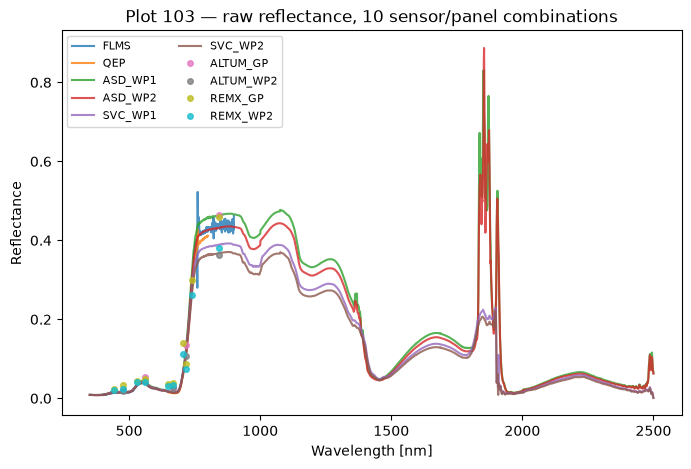

In [2]:
# Step 1a: read the sheet Reflectance_<plot>_all. The data start at row 3 (rows 1-2 are headers); the number of spectral rows is
# counted until the first completely empty row, and the 60 columns are copied into an array A
ws = wb[f"Reflectance_{PLOT_ID}_all"]
nrows = 0
for r in ws.iter_rows(min_row=3, values_only=True):
    if all(v is None for v in r[:60]):
        break
    nrows += 1

A = np.full((nrows, 60), np.nan)
for i, row in enumerate(ws.iter_rows(min_row=3, max_row=2 + nrows, values_only=True)):
    for c in range(60):
        v = row[c]
        A[i, c] = np.nan if v is None else v

# helper: column c of the sheet (counted from 1, as in the MATLAB code)
def col(c):  # 1-indexed column, matching the original code
    return A[:, c - 1]

# Step 1b: one block of columns per sensor / panel (columns counted from 1):
#   FLMS, QEP (7 columns each)      : wavelength, reflectance, u_random, u_systematic, (blank), u_combined (1 sigma), U_expanded (k=2)
#   ASD, SVC                        : one shared wavelength column, then the WP1 / WP2 reflectance and uncertainty columns interleaved
#   Altum, REMX (GP and WP2, 6 each): wavelength, reflectance, u_panel, u_plot, u_ROI, u_total (already combined)
FLMS = np.column_stack([col(c) for c in range(1, 8)])
QEP = np.column_stack([col(c) for c in range(8, 15)])
ASD_WP1 = np.column_stack([col(15), col(16), col(18), col(20), col(22), col(24)])
ASD_WP2 = np.column_stack([col(15), col(17), col(19), col(21), col(23), col(25)])
SVC_WP1 = np.column_stack([col(26), col(27), col(29), col(31), col(33), col(35)])
SVC_WP2 = np.column_stack([col(26), col(28), col(30), col(32), col(34), col(36)])
Altum_GP = np.column_stack([col(c) for c in range(37, 43)])
Altum_WP2 = np.column_stack([col(c) for c in range(43, 49)])
REMX_GP = np.column_stack([col(c) for c in range(49, 55)])
REMX_WP2 = np.column_stack([col(c) for c in range(55, 61)])

# Step 1c: list of the sensors: name, data block, and position (within the block, counted from 1) of the combined uncertainty
# (name, block, index of the combined-uncertainty column within that block, 1-indexed)
sensors = [
    ("FLMS", FLMS, 6), ("QEP", QEP, 6),
    ("ASD_WP1", ASD_WP1, 5), ("ASD_WP2", ASD_WP2, 5),
    ("SVC_WP1", SVC_WP1, 5), ("SVC_WP2", SVC_WP2, 5),
    ("ALTUM_GP", Altum_GP, 6), ("ALTUM_WP2", Altum_WP2, 6),
    ("REMX_GP", REMX_GP, 6), ("REMX_WP2", REMX_WP2, 6),
]
# keep only the sensors that have data for this plot (e.g. plots other than 103, 105, 203 have no ASD / SVC)
sensors = [sn for sn in sensors if np.isfinite(sn[1][:, 1]).any()]
print(f"Loaded {nrows} spectral rows for Plot {PLOT_ID}.")

# Step 2: plot the reflectance of all sensors: lines for the hyperspectral instruments, points for the multispectral cameras
plt.figure(figsize=(8, 5))
for name, block, ucol in sensors:
    w, r, u = block[:, 0], block[:, 1], block[:, ucol - 1]
    m = np.isfinite(w) & np.isfinite(r)
    style = 'o' if ("ALTUM" in name or "REMX" in name) else '-'
    plt.plot(w[m], r[m], style, label=name, markersize=4, alpha=0.8)
plt.xlabel('Wavelength [nm]'); plt.ylabel('Reflectance')
plt.legend(fontsize=8, ncol=2); plt.title(f'Plot {PLOT_ID} — raw reflectance, {len(sensors)} sensor/panel combinations')
plt.show()

## Step 3 - Match the wavelengths of two sensors

In [3]:
# Step 3a: FLMS, QEP, ASD and SVC are hyperspectral (dense sampling); Altum and REMX are multispectral (a few band centres).
# Three matching strategies are used, depending on the pair of sensors compared:
def is_multispectral(name):
    return "ALTUM" in name or "REMX" in name

# extract wavelength, reflectance and combined uncertainty of a block (valid values only, sorted by wavelength)
def extract_wru(B, ucol):
    w, r, u = B[:, 0], B[:, 1], B[:, ucol - 1]
    m = np.isfinite(w) & np.isfinite(r) & np.isfinite(u)
    w, r, u = w[m], r[m], u[m]
    idx = np.argsort(w)
    return w[idx], r[idx], u[idx]

# (1) hyperspectral vs hyperspectral: both spectra are linearly interpolated onto a common 1 nm grid over their overlapping range
def match_hyperspec_pair(BX, uX, BY, uY, grid_nm=1.0):
    wx, rx, ux = extract_wru(BX, uX)
    wy, ry, uy = extract_wru(BY, uY)
    wlmin, wlmax = max(wx.min(), wy.min()), min(wx.max(), wy.max())
    if wlmax <= wlmin:
        return (np.array([]),) * 5
    wl = np.arange(np.ceil(wlmin), np.floor(wlmax) + 1, grid_nm)
    Rx = np.interp(wl, wx, rx, left=np.nan, right=np.nan)
    ucx = np.interp(wl, wx, ux, left=np.nan, right=np.nan)
    Ry = np.interp(wl, wy, ry, left=np.nan, right=np.nan)
    ucy = np.interp(wl, wy, uy, left=np.nan, right=np.nan)
    m = np.isfinite(wl) & np.isfinite(Rx) & np.isfinite(Ry) & np.isfinite(ucx) & np.isfinite(ucy)
    return wl[m], Rx[m], ucx[m], Ry[m], ucy[m]

# (2) hyperspectral vs multispectral: the hyperspectral spectrum is linearly interpolated onto the band centres of the camera
def match_hyperspec_to_multispec(Bhyp, uHyp, Bmulti, uMulti):
    wm, rm, um = extract_wru(Bmulti, uMulti)
    wh, rh, uh = extract_wru(Bhyp, uHyp)
    if len(wh) < 2 or len(wm) == 0:
        return (np.array([]),) * 5
    Rh = np.interp(wm, wh, rh, left=np.nan, right=np.nan)
    uch = np.interp(wm, wh, uh, left=np.nan, right=np.nan)
    m = np.isfinite(wm) & np.isfinite(Rh) & np.isfinite(uch) & np.isfinite(rm) & np.isfinite(um)
    return wm[m], Rh[m], uch[m], rm[m], um[m]

# (3) multispectral vs multispectral: bands are matched by the nearest wavelength, accepted if within tol (1 nm)
def match_multispec_pair(BX, uX, BY, uY, tol=1.0):
    wx, rx, ux = extract_wru(BX, uX)
    wy, ry, uy = extract_wru(BY, uY)
    wl, Rx, ucx, Ry, ucy = [], [], [], [], []
    for i in range(len(wx)):
        d = np.abs(wy - wx[i])
        j = np.argmin(d)
        if d[j] <= tol:
            wl.append(wx[i]); Rx.append(rx[i]); ucx.append(ux[i])
            Ry.append(ry[j]); ucy.append(uy[j])
    return tuple(np.array(v) for v in (wl, Rx, ucx, Ry, ucy))

# selects the strategy for a pair of sensors; returns wavelength, R and u_c of sensor x, R and u_c of sensor y
def match_pair_general(nameX, BX, uX, nameY, BY, uY):
    isX, isY = is_multispectral(nameX), is_multispectral(nameY)
    if not isX and not isY:
        return match_hyperspec_pair(BX, uX, BY, uY)
    elif not isX and isY:
        return match_hyperspec_to_multispec(BX, uX, BY, uY)
    elif isX and not isY:
        wl, Ry, ucy, Rx, ucx = match_hyperspec_to_multispec(BY, uY, BX, uX)
        return wl, Rx, ucx, Ry, ucy
    else:
        return match_multispec_pair(BX, uX, BY, uY)

## Step 4 - E_N agreement of the reflectance, FLMS against every other sensor

FLMS vs QEP       : N= 149  r=0.996  bias=+0.01120  %|En|<=1= 96.0%  %|En|<=2= 99.3%
FLMS vs ASD_WP1   : N= 499  r=0.999  bias=-0.01112  %|En|<=1= 98.8%  %|En|<=2= 99.8%
FLMS vs ASD_WP2   : N= 499  r=0.999  bias=+0.00019  %|En|<=1= 99.6%  %|En|<=2= 99.8%
FLMS vs SVC_WP1   : N= 499  r=0.999  bias=+0.01377  %|En|<=1= 98.2%  %|En|<=2=100.0%
FLMS vs SVC_WP2   : N= 499  r=0.999  bias=+0.02191  %|En|<=1= 93.8%  %|En|<=2=100.0%
FLMS vs ALTUM_GP  : N=   5  r=1.000  bias=-0.01778  %|En|<=1= 20.0%  %|En|<=2= 20.0%
FLMS vs ALTUM_WP2 : N=   5  r=1.000  bias=+0.01161  %|En|<=1= 60.0%  %|En|<=2= 80.0%
FLMS vs REMX_GP   : N=  10  r=0.984  bias=-0.01647  %|En|<=1= 20.0%  %|En|<=2= 30.0%
FLMS vs REMX_WP2  : N=  10  r=0.987  bias=+0.00236  %|En|<=1= 20.0%  %|En|<=2= 50.0%


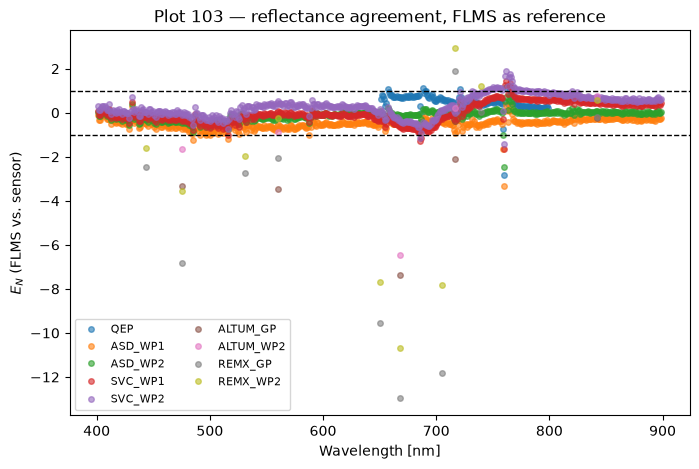

In [4]:
# Step 4a: E_N = (Rx - Ry) / sqrt(ucx^2 + ucy^2) and statistics of the agreement: number of matched points, Pearson correlation,
# mean bias, RMSE, mean E_N, and the percentage of points with |E_N| <= 1 and <= 2
def en_metrics(wl, Rx, ucx, Ry, ucy):
    den = np.sqrt(ucx**2 + ucy**2)
    En = (Rx - Ry) / den
    r = np.corrcoef(Rx, Ry)[0, 1] if len(Rx) > 1 else np.nan
    return dict(
        N=len(wl), r_Pearson=r,
        bias_mean=np.nanmean(Rx - Ry),
        RMSE=np.sqrt(np.nanmean((Rx - Ry) ** 2)),
        En_mean=np.nanmean(En),
        pct_absEn_le_1=100 * np.mean(np.abs(En) <= 1),
        pct_absEn_le_2=100 * np.mean(np.abs(En) <= 2),
    ), En

# Step 4b: FLMS (reference) against each of the other 9 sensor / panel combinations
reflectance_results = {}
for name, block, ucol in sensors:
    if name == "FLMS":
        continue
    wl, Rx, ucx, Ry, ucy = match_pair_general("FLMS", FLMS, 6, name, block, ucol)
    if len(wl) < 3:
        print(f"FLMS vs {name}: not enough spectral overlap")
        continue
    M, En = en_metrics(wl, Rx, ucx, Ry, ucy)
    reflectance_results[name] = (wl, En, M)
    print(f"FLMS vs {name:10s}: N={M['N']:4d}  r={M['r_Pearson']:.3f}  "
          f"bias={M['bias_mean']:+.5f}  %|En|<=1={M['pct_absEn_le_1']:5.1f}%  %|En|<=2={M['pct_absEn_le_2']:5.1f}%")

# Step 4c: E_N per wavelength, one coloured point series per sensor; the dashed lines mark |E_N| = 1
plt.figure(figsize=(8, 5))
for name, (wl, En, M) in reflectance_results.items():
    plt.plot(wl, En, 'o', label=name, markersize=4, alpha=0.6)
plt.axhline(1, color='k', linestyle='--', linewidth=1)
plt.axhline(-1, color='k', linestyle='--', linewidth=1)
plt.xlabel('Wavelength [nm]'); plt.ylabel('$E_N$ (FLMS vs. sensor)')
plt.legend(fontsize=8, ncol=2); plt.title(f'Plot {PLOT_ID} — reflectance agreement, FLMS as reference')
plt.show()

## Step 5 - E_N agreement of the vegetation indices

In [5]:
# Step 5a: sheet Indexes<plot>: one row per sensor at fixed row numbers, as read by the MATLAB code
ws2 = wb[f"Indexes{PLOT_ID}"]
row_map = {"FLMS": 8, "QEP": 16, "ASD_WP1": 20, "ASD_WP2": 21,
           "SVC_WP1": 26, "SVC_WP2": 27, "ALTUM_GP": 31, "ALTUM_WP2": 32,
           "REMX_GP": 37, "REMX_WP2": 38}
# (the dictionary index_start gives the first column of each index block)
# each index occupies 7 columns: point, value, u_r, u_s, u_homogeneity, u_c, U_k2
index_start = {"PRI": 1, "NDVI": 7, "NIRv": 13, "EVI": 19, "MTCI": 25, "OSAVI": 31}

# value and combined uncertainty (u_c) of an index for a sensor
def get_index_val_uc(sensor, idx_name):
    r = row_map[sensor]
    start = index_start[idx_name]
    val = ws2.cell(row=r, column=start + 1).value
    uc = ws2.cell(row=r, column=start + 5).value
    return val, uc

# Step 5b: E_N of each index for FLMS against every other sensor; indices that a sensor does not have (empty cells) are skipped
index_results = {}
for idx_name in ["NDVI", "EVI", "OSAVI", "MTCI", "PRI"]:
    val_f, uc_f = get_index_val_uc("FLMS", idx_name)
    if val_f is None:
        continue
    print(f"\n{idx_name} (FLMS = {val_f:.4f} +/- {uc_f:.4f}):")
    for name in row_map:
        if name == "FLMS":
            continue
        val_y, uc_y = get_index_val_uc(name, idx_name)
        if val_y is None or uc_f is None or uc_y is None:
            print(f"  vs {name:10s}: no data")
            continue
        En = (val_f - val_y) / np.sqrt(uc_f**2 + uc_y**2)
        index_results[(idx_name, name)] = En
        print(f"  vs {name:10s}: {idx_name}={val_y:+.4f}  En={En:+.3f}  |En|<=1: {'yes' if abs(En) <= 1 else 'no'}")


NDVI (FLMS = 0.9361 +/- 0.0031):
  vs QEP       : NDVI=+0.9391  En=-0.840  |En|<=1: yes
  vs ASD_WP1   : NDVI=+0.9346  En=+0.154  |En|<=1: yes
  vs ASD_WP2   : NDVI=+0.9348  En=+0.127  |En|<=1: yes
  vs SVC_WP1   : NDVI=+0.9205  En=+1.165  |En|<=1: no
  vs SVC_WP2   : NDVI=+0.9208  En=+1.422  |En|<=1: no
  vs ALTUM_GP  : NDVI=+0.8865  En=+6.511  |En|<=1: no
  vs ALTUM_WP2 : NDVI=+0.8673  En=+7.985  |En|<=1: no
  vs REMX_GP   : NDVI=+0.8512  En=+14.037  |En|<=1: no
  vs REMX_WP2  : NDVI=+0.8439  En=+14.753  |En|<=1: no

EVI (FLMS = 0.7263 +/- 0.0777):
  vs QEP       : no data
  vs ASD_WP1   : EVI=+0.7315  En=-0.059  |En|<=1: yes


  vs ASD_WP2   : EVI=+0.7668  En=-0.446  |En|<=1: yes
  vs SVC_WP1   : EVI=+0.6685  En=+0.636  |En|<=1: yes
  vs SVC_WP2   : EVI=+0.6407  En=+1.011  |En|<=1: no
  vs ALTUM_GP  : EVI=+0.7512  En=-0.318  |En|<=1: yes
  vs ALTUM_WP2 : EVI=+0.6126  En=+1.456  |En|<=1: no
  vs REMX_GP   : EVI=+0.7001  En=+0.336  |En|<=1: yes
  vs REMX_WP2  : EVI=+0.6121  En=+1.468  |En|<=1: no

OSAVI (FLMS = 0.7926 +/- 0.0327):
  vs QEP       : OSAVI=+0.7857  En=+0.193  |En|<=1: yes
  vs ASD_WP1   : OSAVI=+0.7924  En=+0.007  |En|<=1: yes
  vs ASD_WP2   : OSAVI=+0.8067  En=-0.356  |En|<=1: yes
  vs SVC_WP1   : OSAVI=+0.7596  En=+0.793  |En|<=1: yes
  vs SVC_WP2   : OSAVI=+0.7471  En=+1.194  |En|<=1: no
  vs ALTUM_GP  : OSAVI=+0.7765  En=+0.483  |En|<=1: yes


  vs ALTUM_WP2 : OSAVI=+0.7130  En=+2.382  |En|<=1: no
  vs REMX_GP   : OSAVI=+0.7462  En=+1.402  |En|<=1: no
  vs REMX_WP2  : OSAVI=+0.7058  En=+2.622  |En|<=1: no

MTCI (FLMS = 5.3359 +/- 0.1587):
  vs QEP       : MTCI=+5.0638  En=+1.376  |En|<=1: no
  vs ASD_WP1   : MTCI=+4.9845  En=+0.339  |En|<=1: yes
  vs ASD_WP2   : MTCI=+4.9664  En=+0.304  |En|<=1: yes
  vs SVC_WP1   : MTCI=+4.3572  En=+0.837  |En|<=1: yes
  vs SVC_WP2   : MTCI=+4.3548  En=+1.124  |En|<=1: no
  vs ALTUM_GP  : no data
  vs ALTUM_WP2 : no data
  vs REMX_GP   : no data


  vs REMX_WP2  : no data

PRI (FLMS = 0.0117 +/- 0.0072):
  vs QEP       : no data
  vs ASD_WP1   : PRI=-0.0005  En=+0.144  |En|<=1: yes
  vs ASD_WP2   : PRI=+0.0009  En=+0.111  |En|<=1: yes
  vs SVC_WP1   : PRI=-0.0153  En=+0.277  |En|<=1: yes
  vs SVC_WP2   : PRI=-0.0150  En=+0.339  |En|<=1: yes
  vs ALTUM_GP  : no data
  vs ALTUM_WP2 : no data
  vs REMX_GP   : PRI=-0.0543  En=+5.761  |En|<=1: no
  vs REMX_WP2  : PRI=-0.0064  En=+2.408  |En|<=1: no


## Step 6 - Summary table

In [6]:
# Step 6: table of E_N, indices (rows) against sensors (columns); green = good agreement, red = poor agreement
idx_names = ["NDVI", "EVI", "OSAVI", "MTCI", "PRI"]
sensor_names = [n for n in row_map if n != "FLMS"]
table = pd.DataFrame(index=idx_names, columns=sensor_names, dtype=float)
for (idx_name, name), En in index_results.items():
    table.loc[idx_name, name] = En

table.style.format("{:+.2f}", na_rep="—").background_gradient(cmap="RdYlGn_r", vmin=-3, vmax=3, axis=None)

,QEP,ASD_WP1,ASD_WP2,SVC_WP1,SVC_WP2,ALTUM_GP,ALTUM_WP2,REMX_GP,REMX_WP2
NDVI,-0.84,+0.15,+0.13,+1.16,+1.42,+6.51,+7.98,+14.04,+14.75
EVI,—,-0.06,-0.45,+0.64,+1.01,-0.32,+1.46,+0.34,+1.47
OSAVI,+0.19,+0.01,-0.36,+0.79,+1.19,+0.48,+2.38,+1.40,+2.62
MTCI,+1.38,+0.34,+0.30,+0.84,+1.12,—,—,—,—
PRI,—,+0.14,+0.11,+0.28,+0.34,—,—,+5.76,+2.41


## Step 7 - Plot of the index agreement

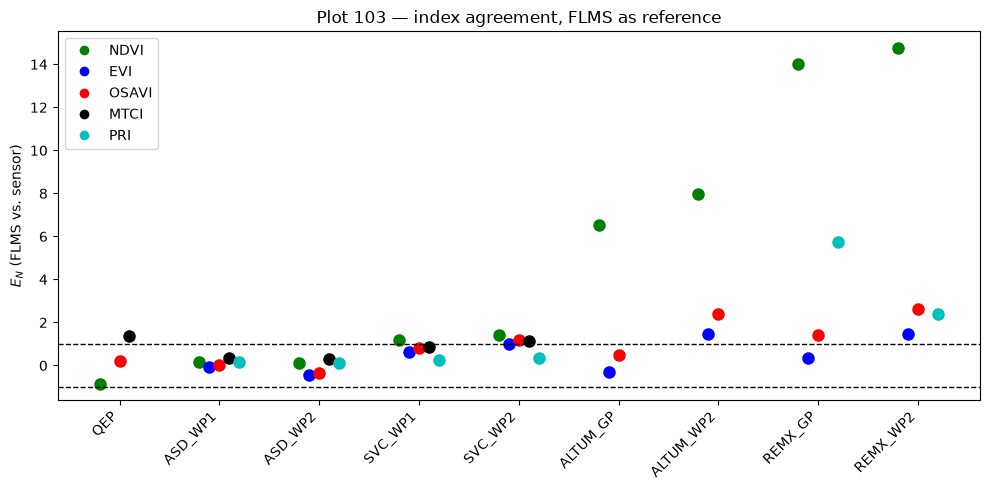

In [7]:
# Step 7: E_N of every index for every sensor (coloured points, one colour per index); dashed lines at |E_N| = 1
fig, ax = plt.subplots(figsize=(10, 5))
index_colors = {'NDVI': 'g', 'EVI': 'b', 'OSAVI': 'r', 'MTCI': 'k', 'PRI': 'c'}
offsets = {'NDVI': -0.2, 'EVI': -0.1, 'OSAVI': 0.0, 'MTCI': 0.1, 'PRI': 0.2}
for x, sensor in enumerate(sensor_names):
    for idx_name, color in index_colors.items():
        val = table.loc[idx_name, sensor]
        if pd.notna(val):
            ax.plot(x + offsets[idx_name], val, 'o', color=color, markersize=8)
ax.axhline(1, color='k', linestyle='--', linewidth=1)
ax.axhline(-1, color='k', linestyle='--', linewidth=1)
ax.set_xticks(range(len(sensor_names))); ax.set_xticklabels(sensor_names, rotation=45, ha='right')
ax.set_ylabel('$E_N$ (FLMS vs. sensor)')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=n)
           for n, c in index_colors.items()]
ax.legend(handles=handles)
ax.set_title(f'Plot {PLOT_ID} — index agreement, FLMS as reference')
plt.tight_layout(); plt.show()

---

**Code:** L. Mihai (laura.mihai@inflpr.ro) and Mike Werfeli (mike.werfeli@geo.uzh.ch)  
**Training material:** L. Mihai (laura.mihai@inflpr.ro)